<h1 style="text-align:center;">Binding mode experimental structures</h1>

In [6]:
import glob
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from Bio.PDB import PDBParser, NeighborSearch

from Bio.SeqUtils import seq1

import re


# Segment and epitope distribution 

273


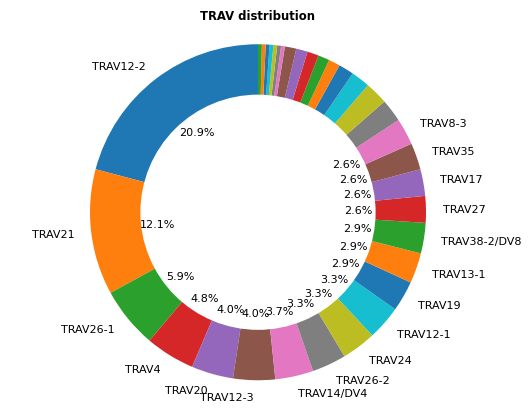

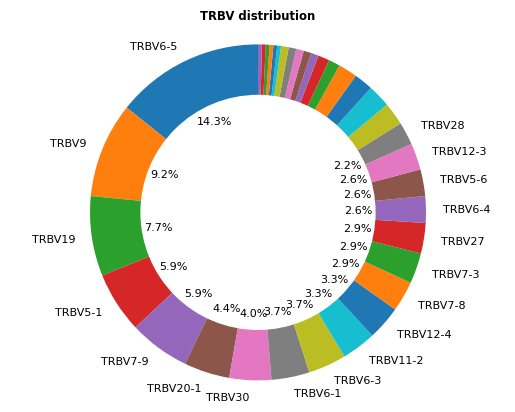

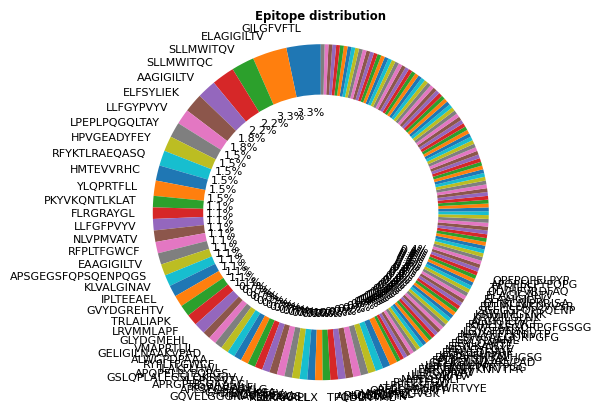

In [29]:
df = pd.read_csv('260305_data.csv') 
print(len(df))

variables = ['TRAV', 'TRBV', 'Epitope']
for var in variables:
    fig, ax = plt.subplots()
    
    # count occurrences
    counts = df[var].value_counts()
    wedges, texts, autotexts = ax.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 8})

    # rotate labels
    for i, (text, autotext) in enumerate(zip(texts, autotexts)):
        if i < len(texts)/2:
            pass
        else:
            text.set_text('')
            autotext.set_text('')

    # create donut hole
    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    fig.gca().add_artist(centre_circle)

    ax.axis('equal')  # keep circle shape
    plt.title(f"{var} distribution", fontsize='small', fontweight='bold')

    #fig.savefig(f"{var}_donut.pdf", bbox_inches="tight")

# CDR1/2 : peptide / MHC contacts

In [88]:
def extract_cdr_resids(pdb_path, cdr_dict, chain_map={"TRA":"A","TRB":"B"}):
    """
    Extract residue id of CDRs based on the respective sequences.
    """
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("pdb", pdb_path)
    
    cdr_resids = {}
    for cdr_name, cdr_seq in cdr_dict.items():
        # get tcr chain
        chain_id = chain_map[cdr_name.split('_')[-1]]
        chain_obj = structure[0][chain_id]

        # Get all residues with C-alpha
        residues = [res for res in chain_obj if res.id[0] == " " and "CA" in res]

        # Convert 3-letter PDB codes to 1-letter
        seq = "".join([seq1(res.get_resname()) for res in residues])
 
        # find CDR sequence in the chain sequence
        L = len(cdr_seq)
        start_idx = seq.find(cdr_seq)
        if start_idx == -1:
            print(f"Warning: CDR {cdr_name} sequence not found in chain {chain_id} of {pdb_path}")
            return None
        
        end_idx = start_idx + L
        
        # extract cdr resids
        resids = np.array([res.get_id()[1] for res in residues[start_idx:end_idx]])
        cdr_resids[cdr_name] = resids

    return cdr_resids


def compute_cdr_min_distances(pdb_file, cdr_resids, chain_map, sel_epitope):
    """
    Extract minimal CA–CA distances between CDR residues and pMHC.
    """
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("tcr", pdb_file)
    
    # Collect CA atoms of epitope chains
    epitope_atoms = []
    for chain_id in chain_map[sel_epitope]:
        chain = structure[0][chain_id]
        epitope_atoms.extend(
            atom for atom in chain.get_atoms() if atom.get_name() == "CA"
        )
    
    cdr_distances = {}
    
    for cdr, res_nums in cdr_resids.items():
        
        if "TRA" in cdr:
            tcr_chain_id = chain_map["TRA"]
        else:
            tcr_chain_id = chain_map["TRB"]
        
        chain = structure[0][tcr_chain_id]
        distances = []
        
        for res_num in res_nums:
            try:
                res = chain[(' ', res_num, ' ')]
            except KeyError:
                distances.append(np.nan)
                continue
            
            # get CA atom of residue
            if "CA" in res:
                ca_atom = res["CA"]
                
                # compute min CA–CA distance
                min_dist = min(ca_atom - ep_atom for ep_atom in epitope_atoms)
                distances.append(min_dist)
            else:
                distances.append(np.nan)
        
        cdr_distances[cdr] = np.array(distances)
    
    return cdr_distances

def build_dist_matrix(cdr_dist_dict, min_cdr_lengths):
    """
    Build distance matrix with fixed-length CDRs.
    """
    dist_matrix = []
    for pdb, cdrs in cdr_dist_dict.items():
        vec = []
        for cdr_name, distances in cdrs.items():
            L = min_cdr_lengths[cdr_name]
            # first 2 + last L-2
            selected = np.hstack([distances[:2], distances[-(L-2):]])
            vec.extend(selected.flatten())
    
        dist_matrix.append(vec)
    
    return np.array(dist_matrix)
    

In [ ]:
topdir = 'pdbs_mhc_align'
df = pd.read_csv('260305_data_structures.csv')
df = df.rename(columns={'CDR1A': 'cdr1_TRA', 'CDR2A': 'cdr2_TRA', 'CDR1B': 'cdr1_TRB', 'CDR2B': 'cdr2_TRB'})

cdr_dist_dict = {}
for idx, row in df.iterrows():
    pdb_file = f'{topdir}/{row.PDB}.pdb'
    #print(row.PDB)
    if not os.path.exists(pdb_file):
        continue
    
    if row.MHC == 'classI':
        chain_map={"TRA":"D","TRB":"E", "MHC":["A"], "peptide":"C"}
    else:
        chain_map={"TRA":"D","TRB":"E", "MHC":["A", "B"], "peptide":"C"}

    cdr_dict = {cdr: str(row[cdr]).upper() for cdr in ["cdr1_TRA","cdr2_TRA","cdr1_TRB","cdr2_TRB"]}

    # get cdr resids
    cdr_resids = extract_cdr_resids(pdb_file, cdr_dict, chain_map)

    # get pMHC distance
    peptide_cdr_min_distances = compute_cdr_min_distances(pdb_file, cdr_resids, chain_map, sel_epitope='peptide')
    cdr_dist_dict[row.PDB] = peptide_cdr_min_distances

# minimal CDR lengths
min_cdr_lengths = {}
for cdr_name in ["cdr1_TRA","cdr2_TRA","cdr1_TRB","cdr2_TRB"]:
    min_len = min(cdr_dist_dict[pdb_id][cdr_name].shape[0] for pdb_id in cdr_dist_dict)
    min_cdr_lengths[cdr_name] = min_len

# build distance matrix 
dist_matrix = build_dist_matrix(cdr_dist_dict, min_cdr_lengths)

col_names = [f'{key}.{i+1}' for key in min_cdr_lengths for i in range(min_cdr_lengths[key])]

result = pd.DataFrame(dist_matrix, columns=col_names)
result['PDB'] = cdr_dist_dict.keys()
result = pd.merge(result, df, on='PDB')
result.to_pickle('peptide_dist_matrix.pkl')

19


In [101]:
print(min_cdr_lengths)

{'cdr1_TRA': 5, 'cdr2_TRA': 4, 'cdr1_TRB': 5, 'cdr2_TRB': 5}


<>:9: SyntaxWarning: invalid escape sequence '\.'
<>:9: SyntaxWarning: invalid escape sequence '\.'
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_61613/2756693512.py:9: SyntaxWarning: invalid escape sequence '\.'
  data = df.filter(regex=f'cdr[12]_TR{chain}\..+')


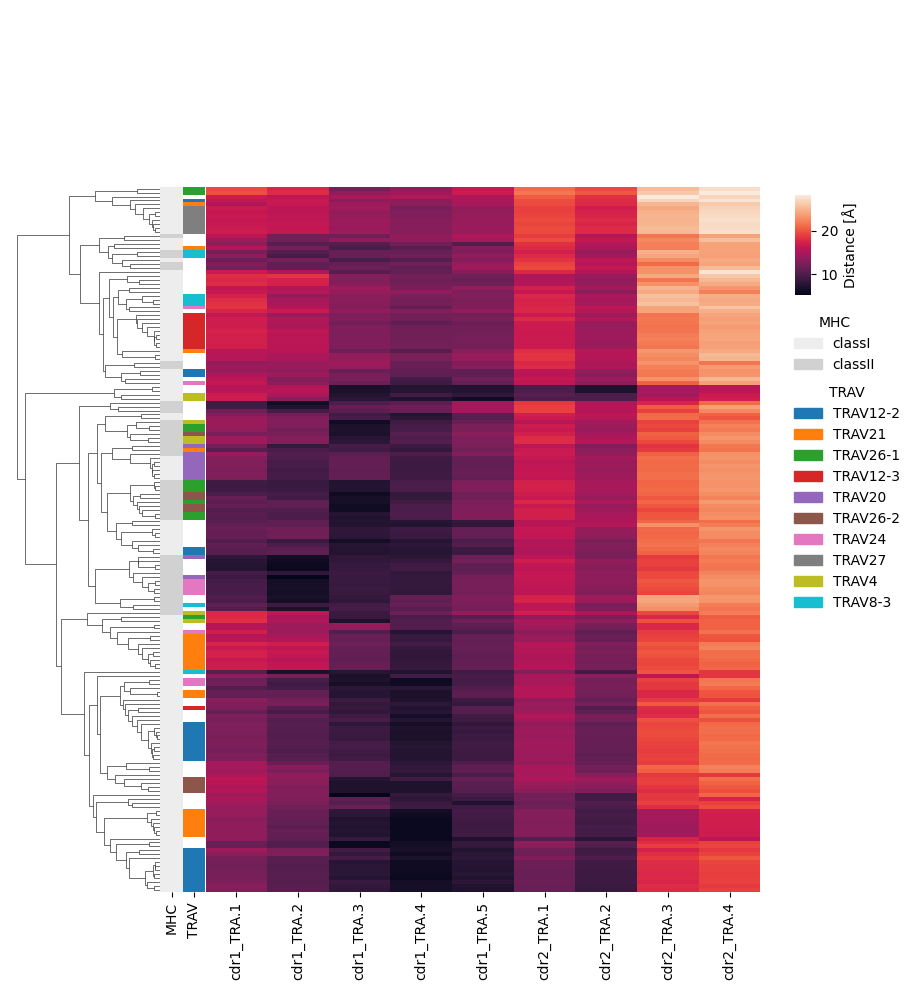

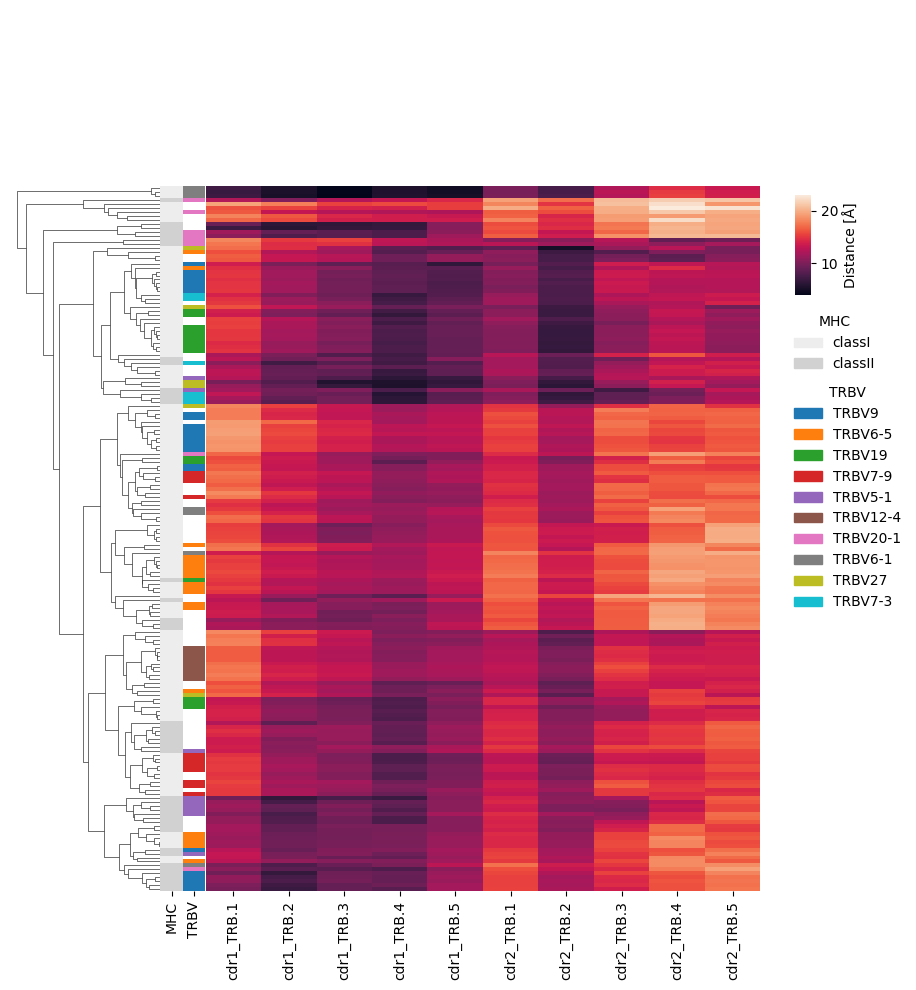

In [151]:
chains = ['A', 'B']

for chain in chains:
    # plot
    df = pd.read_pickle('peptide_dist_matrix.pkl')
    df.set_index('PDB', inplace=True)

    # distance data
    data = df.filter(regex=f'cdr[12]_TR{chain}\..+')

    # annotations
    meta = df[[f'TR{chain}V', 'MHC', 'Epitope']]
    meta.set_index(data.index, inplace=True)

    mhc_colors = dict(zip(meta["MHC"].unique(), sns.color_palette("Greys")))
    v_colors = dict(zip(meta[f'TR{chain}V'].value_counts().index.to_list()[:10], sns.color_palette("tab10")))

    row_colors = pd.DataFrame({
        "MHC": meta["MHC"].map(mhc_colors),
        f"TR{chain}V": meta[f"TR{chain}V"].map(v_colors),
    })

    g = sns.clustermap(
        data,
        row_colors=row_colors,
        col_cluster=False,
        figsize=(8,10),
        yticklabels =False,
        cbar_kws={"label": "Distance [Å]"}  # <-- distance colorbar label
    )

    g.ax_heatmap.set_ylabel("")
    g.cax.set_position([1, 0.7, 0.02, 0.1])  

    # create legend handles for MHC
    mhc_handles = [mpatches.Patch(color=color, label=label) for label, color in mhc_colors.items()]
    # legend handles for TRAV/TRBV
    v_handles = [mpatches.Patch(color=color, label=label) for label, color in v_colors.items()]

    # place the legends on the right
    mhc_legend = g.ax_heatmap.legend(handles=mhc_handles, 
                        bbox_to_anchor=(1.05, 0.825),  # right of heatmap
                        loc='upper left', 
                        borderaxespad=0.,
                        title="MHC",
                        frameon=False)
    
    g.ax_heatmap.add_artist(mhc_legend)
    g.ax_heatmap.legend(handles=v_handles, 
                        bbox_to_anchor=(1.05, 0.725),  # right of heatmap
                        loc='upper left', 
                        borderaxespad=0.,
                        title=f"TR{chain}V",
                        frameon=False)
    

# UMAP

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import umap

/Users/roessner/miniconda3/envs/umap_env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/roessner/miniconda3/envs/umap_env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


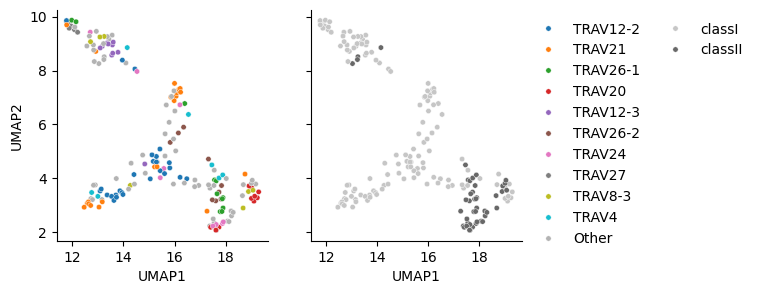

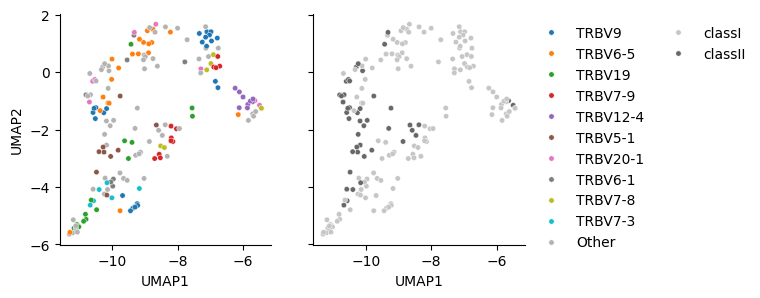

In [26]:
chains = ['A', 'B']

for chain in chains:
    # load data
    df = pd.read_pickle('peptide_dist_matrix.pkl')
    df.set_index('PDB', inplace=True)

    # distance data (columns with dot)
    data = df.filter(regex=f'cdr[12]_TR{chain}\..+')
    
    # annotations
    meta = df[[f'TR{chain}V', 'MHC']].copy()
    
    # identify 10 most common TR{chain}V genes
    top10 = meta[f'TR{chain}V'].value_counts().index[:10].tolist()
    
    # replace the rest with 'Other'
    meta['TRV_group'] = meta[f'TR{chain}V'].apply(lambda x: x if x in top10 else 'Other')

    # define colors
    palette = sns.color_palette("tab10", n_colors=len(top10))
    # add one color for 'Other'
    palette.append((0.7,0.7,0.7))  # light gray
    trv_colors = dict(zip(top10 + ['Other'], palette))

    # run UMAP
    reducer = umap.UMAP(random_state=42)
    embedding = reducer.fit_transform(data.values)
    
    df_umap = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'])
    df_umap[f'TR{chain}V'] = meta['TRV_group'].values
    df_umap['MHC'] = meta['MHC'].values

    fig, axes = plt.subplots(1,2,figsize=(6,3), sharex=True, sharey=True)
    vars = [f'TR{chain}V', 'MHC']

    for cnt, var in enumerate(vars):
        ax = axes[cnt]
        if var == "MHC":
            sns.scatterplot(df_umap, x='UMAP1', y='UMAP2', hue=var, ax=ax, palette='Greys', s=15)
            ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1.6,1))
        else:
            sns.scatterplot(df_umap, x='UMAP1', y='UMAP2', hue=var, ax=ax, palette=trv_colors, hue_order=top10 + ['Other'], s=15)
            ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(2.2,1))


    sns.despine()

/Users/roessner/miniconda3/envs/umap_env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


         UMAP1     UMAP2      TRAV     MHC   PDB
0    15.426519  5.089913  TRAV12-2  classI  1AO7
6    15.289597  4.814495  TRAV12-2  classI  1QRN
7    15.165664  4.633157  TRAV12-2  classI  1QSE
8    15.291437  4.607385  TRAV12-2  classI  1QSF
14   15.814077  4.389399  TRAV12-2  classI  2GJ6
25   15.796375  4.584244  TRAV12-2  classI  3H9S
36   15.437467  4.286103  TRAV12-2  classI  3PWP
41   15.607942  4.180459  TRAV12-2  classI  3QFJ
53   15.116693  4.873817  TRAV12-2  classI  4FTV
104  15.049656  3.985612  TRAV12-2  classI  6AMU
130  16.478512  3.989332  TRAV12-2  classI  7N1F
147  16.216816  4.041968  TRAV12-2  classI  7RTR


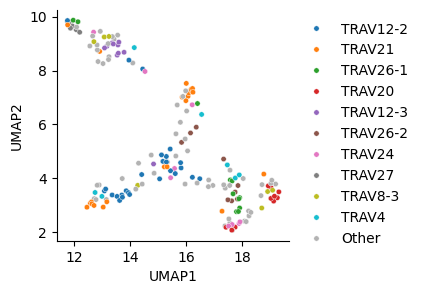

In [40]:
chains = ['A']

for chain in chains:
    # load data
    df = pd.read_pickle('peptide_dist_matrix.pkl')
    df.set_index('PDB', inplace=True)

    # distance data (columns with dot)
    data = df.filter(regex=f'cdr[12]_TR{chain}\..+')
    
    # annotations
    meta = df[[f'TR{chain}V', 'MHC']].copy()

    # identify 10 most common TR{chain}V genes
    top10 = meta[f'TR{chain}V'].value_counts().index[:10].tolist()
    
    # replace the rest with 'Other'
    meta['TRV_group'] = meta[f'TR{chain}V'].apply(lambda x: x if x in top10 else 'Other')

    # define colors
    palette = sns.color_palette("tab10", n_colors=len(top10))
    # add one color for 'Other'
    palette.append((0.7,0.7,0.7))  # light gray
    trv_colors = dict(zip(top10 + ['Other'], palette))

    # run UMAP
    reducer = umap.UMAP(random_state=42)
    embedding = reducer.fit_transform(data.values)
    
    df_umap = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'])
    df_umap[f'TR{chain}V'] = meta['TRV_group'].values
    df_umap['MHC'] = meta['MHC'].values
    df_umap['PDB'] = meta.index

    fig, ax = plt.subplots(1,1,figsize=(3,3))

    sns.scatterplot(df_umap, x='UMAP1', y='UMAP2', hue='TRAV', ax=ax, palette=trv_colors, hue_order=top10 + ['Other'], s=15)
    ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1,1))

    sns.despine()

    tmp = df_umap[df_umap['TRAV'] == 'TRAV12-2']
    tmp = tmp[tmp['UMAP1'] > 15]
    print(tmp)

# Motifs

In [26]:
def get_chain_sequence(pdb_file, chain_id):
    """
    Get sequence based on chain id.
    """
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("tcr", pdb_file)

    seq = []
    for res in structure[0][chain_id]: 
        seq.append(seq1(res.get_resname()))

    return "".join(seq)


def extract_cdr3(sequence, min_len=7, max_len=23):
    """
    Extract CDR3 using conserved C (start) and the F/W-GxG motif (end). Ensures min_len <= CDR3 length <= max_len.
    """
    # find all conserved C positions
    c_positions = [m.start() for m in re.finditer("C", sequence)]
    if not c_positions:
        return None

    # try Cs from last to first (most likely real CDR3 start)
    for c_pos in reversed(c_positions):
        subseq = sequence[c_pos:]

        # find all FGXG / WGXG motifs after this C
        matches = list(re.finditer(r"([FW])G.G", subseq))
        if not matches:
            continue

        # check motifs from LAST to FIRST
        for match in reversed(matches):
            end = c_pos + match.start(1) + 1
            cdr3 = sequence[c_pos:end]

            L = len(cdr3)
            if min_len <= L <= max_len:
                return cdr3

    return None

def inferJ(cdr3_query, gene):
    """
    Infer J segement from CDR3 sequence.
    """

    df_gene = pd.read_csv(f'/Users/roessner/Documents/PostDoc/Data/MixTCRviz/data_raw/HomoSapiens/{gene}.csv')
    df_gene = df_gene.rename(columns={df_gene.columns[0]:gene})

    print(df_gene.head())

    best_gene = None
    best_score = 0

    for _, row in df_gene.iterrows():
        j_cdr3 = row["CDR3"]

        # try all suffix overlaps
        max_len = min(len(cdr3_query), len(j_cdr3))

        for k in range(1, max_len + 1):
            if cdr3_query[-k:] == j_cdr3[-k:]:
                if k > best_score:
                    best_score = k
                    best_gene = row[gene]

    return best_gene

In [28]:
topdir = 'pdbs_mhc_align'
df = pd.read_csv('260305_data_structures.csv')
df = df.rename(columns={'CDR1A': 'cdr1_TRA', 'CDR2A': 'cdr2_TRA', 'CDR1B': 'cdr1_TRB', 'CDR2B': 'cdr2_TRB'})

cdr_dist_dict = {}
for idx, row in df.iterrows():
    pdb_file = f'{topdir}/{row.PDB}.pdb'
    #print(row.PDB)
    if not os.path.exists(pdb_file):
        continue

    # get TCR chains
    seq_a = get_chain_sequence(pdb_file, "D")
    seq_b = get_chain_sequence(pdb_file, "E")

    # extract CDR3
    cdr3a = extract_cdr3(seq_a)
    cdr3b = extract_cdr3(seq_b)

    if (cdr3a is None) | (cdr3b is None):
        continue

    df.loc[idx, 'cdr3_TRA'] = cdr3a
    df.loc[idx, 'cdr3_TRB'] = cdr3b

    # infer J
    TRAJ = inferJ(cdr3a, 'TRAJ')
    TRBJ = inferJ(cdr3b, 'TRBJ')

    df.loc[idx, 'TRAJ'] = TRAJ
    df.loc[idx, 'TRBJ'] = TRBJ

df['model'] = 'exp.structures'
df.to_csv('260305_data_structures_motif.csv', index=False)

     TRAJ         CDR3 CDR3_end  ext default_allele gene_type  \
0   TRAJ1   YESITSQLQF     QLQF  GKG            *01       ORF   
1  TRAJ10  ILTGGGNKLTF     KLTF  GTG            *01         F   
2  TRAJ11    NSGYSTLTF     TLTF  GKG            *01         F   
3  TRAJ12    MDSSYKLIF     KLIF  GSG            *01         F   
4  TRAJ13   NSGGYQKVTF     KVTF  GTG            *02         F   

                    full  
0   YESITSQLQFGKGTRVSTSP  
1  ILTGGGNKLTFGTGTQLKVEL  
2    NSGYSTLTFGKGTMLLVSP  
3    MDSSYKLIFGSGTRLLVRP  
4   NSGGYQKVTFGTGTKLQVIP  
      TRBJ     CDR3 CDR3_end  ext default_allele gene_type              full
0  TRBJ1-1   NTEAFF     EAFF  GQG            *01         F   NTEAFFGQGTRLTVV
1  TRBJ1-2   NYGYTF     GYTF  GSG            *01         F   NYGYTFGSGTRLTVV
2  TRBJ1-3  SGNTIYF     TIYF  GEG            *01         F  SGNTIYFGEGSWLTVV
3  TRBJ1-4  TNEKLFF     KLFF  GSG            *01         F  TNEKLFFGSGTQLSVL
4  TRBJ1-5  SNQPQHF     PQHF  GDG            *01         F  SN